## Implementation of DGCNN (Model-1) 

In [1]:
# Dependencies & Constants
import numpy
import pandas

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Layer, Lambda, ReLU, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import time
import logging
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

EPOCHS = 20
BATCH_SIZE = 64
NUM_API_CALLS = 307
SEQUENCE_LENGTH = 100

In [ ]:
# An implementation of the Graph Convolution layer from the paper

class GraphConvLayer(Layer):
    """A graph convolutional layer that implements the formula from the paper."""
    
    def __init__(self, output_dim, **kwargs):
        super(GraphConvLayer, self).__init__(**kwargs)
        self.output_dim = output_dim

    def build(self, input_shape):
        self.kernel = self.add_weight(name='kernel',
                                      shape=(input_shape[1][-1], self.output_dim),
                                      initializer='glorot_uniform',
                                      trainable=True)
        super(GraphConvLayer, self).build(input_shape)

    def call(self, inputs):
        adj_matrix, features = inputs
        identity = tf.eye(tf.shape(adj_matrix)[1])
        adj_tilde = adj_matrix + identity
        d_tilde = tf.reduce_sum(adj_tilde, axis=1)
        d_tilde_inv_sqrt = tf.linalg.diag(tf.pow(d_tilde + 1e-6, -0.5))
        adj_normalized = tf.matmul(tf.matmul(d_tilde_inv_sqrt, adj_tilde), d_tilde_inv_sqrt)
        support = tf.matmul(adj_normalized, features)
        output = tf.matmul(support, self.kernel)
        return output

In [3]:
# Model builder helper function
def build_dgcnn_model(seq_len=SEQUENCE_LENGTH, num_apis=NUM_API_CALLS, conv_units=32, dense_units=128):
    """Builds the complete, fully Keras-compatible DGCNN model architecture."""
    input_graph = Input(shape=(num_apis, num_apis), name='graph_input')
    input_sequence = Input(shape=(seq_len,), name='sequence_input')
    
    features = Lambda(
        lambda x: tf.one_hot(tf.cast(x, tf.int32), depth=num_apis),
        name='one_hot_encoding'
    )(input_sequence)
    
    # Transpose the features matrix to be (num_apis, seq_len)
    features_transposed = Lambda(
        lambda x: tf.transpose(x, perm=[0, 2, 1]),
        name='transpose_features'
    )(features)
    
    # Pass the correctly shaped features to the convolution layer
    graph_conv_output = GraphConvLayer(output_dim=conv_units)([input_graph, features_transposed])
    
    graph_conv_output_activated = ReLU()(graph_conv_output)
    
    # Add the missing Dropout layer from the paper
    dropout_layer = Dropout(0.6)(graph_conv_output_activated)
    
    flattened = Flatten()(dropout_layer)
    dense_layer = Dense(dense_units, activation='relu')(flattened)
    output = Dense(1, activation='sigmoid', name='output')(dense_layer)
    
    model = Model(inputs=[input_graph, input_sequence], outputs=output)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

In [4]:
# Build the model
dgcnn_model = build_dgcnn_model()
print("\n--- DGCNN Model Architecture ---")
dgcnn_model.summary()




--- DGCNN Model Architecture ---
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 sequence_input (InputLayer  [(None, 100)]                0         []                            
 )                                                                                                
                                                                                                  
 one_hot_encoding (Lambda)   (None, 100, 307)             0         ['sequence_input[0][0]']      
                                                                                                  
 graph_input (InputLayer)    [(None, 307, 307)]           0         []                            
                                                                                                  
 transpose_features (Lambda  (None, 307, 100)             

In [ ]:
def plot_training_history(history, model_name):
  """Visualizes the model's training and validation performance."""
  plt.figure(figsize=(14, 6))
  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'], label='Training Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.title(f'{model_name} - Accuracy', fontsize=14)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title(f'{model_name} - Loss', fontsize=14)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.suptitle(f'Training History for {model_name}', fontsize=16)
  plt.tight_layout(rect=[0, 0, 1, 0.96])
  plt.savefig(f'results/{model_name}_training_history.png')
  plt.show()

def plot_confusion_matrix_and_roc(y_true, y_pred, y_prob, model_name):
  """Visualizes the confusion matrix and ROC curve for model evaluation."""
  plt.figure(figsize=(16, 7))
  plt.subplot(1, 2, 1)
  cm = confusion_matrix(y_true, y_pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Malware'], yticklabels=['Goodware', 'Malware'])
  plt.title(f'{model_name} - Confusion Matrix', fontsize=14)
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.subplot(1, 2, 2)
  fpr, tpr, _ = roc_curve(y_true, y_prob)
  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'{model_name} - Receiver Operating Characteristic (ROC)', fontsize=14)
  plt.legend(loc="lower right")
  plt.suptitle(f'Evaluation Metrics for {model_name}', fontsize=16)
  plt.savefig(f'results/{model_name}_evaluation_plots.png')
  plt.show()

def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test):
  """A comprehensive function to train a model, evaluate its performance, and generate visualizations."""
  logging.info(f"--- Starting Training for {model_name} ---")
  early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
  start_time = time.time()
  history = model.fit(
      X_train, y_train,
      epochs=EPOCHS,
      batch_size=BATCH_SIZE,
      validation_split=0.2,
      callbacks=[early_stopping],
      verbose=1
  )
  training_time = time.time() - start_time
  logging.info(f"Training for {model_name} completed in {training_time:.2f} seconds.")
  logging.info(f"--- Evaluating {model_name} on the Test Set ---")
  
  if isinstance(X_test, list):
    y_pred_prob = model.predict(X_test).ravel()
  else:
    y_pred_prob = model.predict(X_test).ravel()
    
  y_pred_class = (y_pred_prob > 0.5).astype(int)

  print(f"\n--- Classification Report for {model_name} ---")
  print(classification_report(y_test, y_pred_class, target_names=['Goodware', 'Malware']))
  
  plot_training_history(history, model_name)
  plot_confusion_matrix_and_roc(y_test, y_pred_class, y_pred_prob, model_name)

  return model

Epoch 1/20



22/22 [==============================] - 4s 136ms/step - loss: 0.5115 - accuracy: 0.7688 - auc: 0.8471 - val_loss: 0.3602 - val_accuracy: 0.8353 - val_auc: 0.9201
Epoch 2/20
22/22 [==============================] - 3s 120ms/step - loss: 0.2931 - accuracy: 0.8812 - auc: 0.9520 - val_loss: 0.3106 - val_accuracy: 0.8757 - val_auc: 0.9448
Epoch 3/20
22/22 [==============================] - 3s 127ms/step - loss: 0.2220 - accuracy: 0.9152 - auc: 0.9715 - val_loss: 0.3103 - val_accuracy: 0.8902 - val_auc: 0.9529
Epoch 4/20
22/22 [==============================] - 3s 124ms/step - loss: 0.1856 - accuracy: 0.9312 - auc: 0.9796 - val_loss: 0.2893 - val_accuracy: 0.8931 - val_auc: 0.9556
Epoch 5/20
22/22 [==============================] - 3s 123ms/step - loss: 0.1509 - accuracy: 0.9370 - auc: 0.9874 - val_loss: 0.2743 - val_accuracy: 0.8902 - val_auc: 0.9608
Epoch 6/20
22/22 [==============================] - 3s 124ms/step - loss: 0.1445 - accuracy: 0.9471 - auc: 0.9876 - val_loss: 0.2742 - val_ac

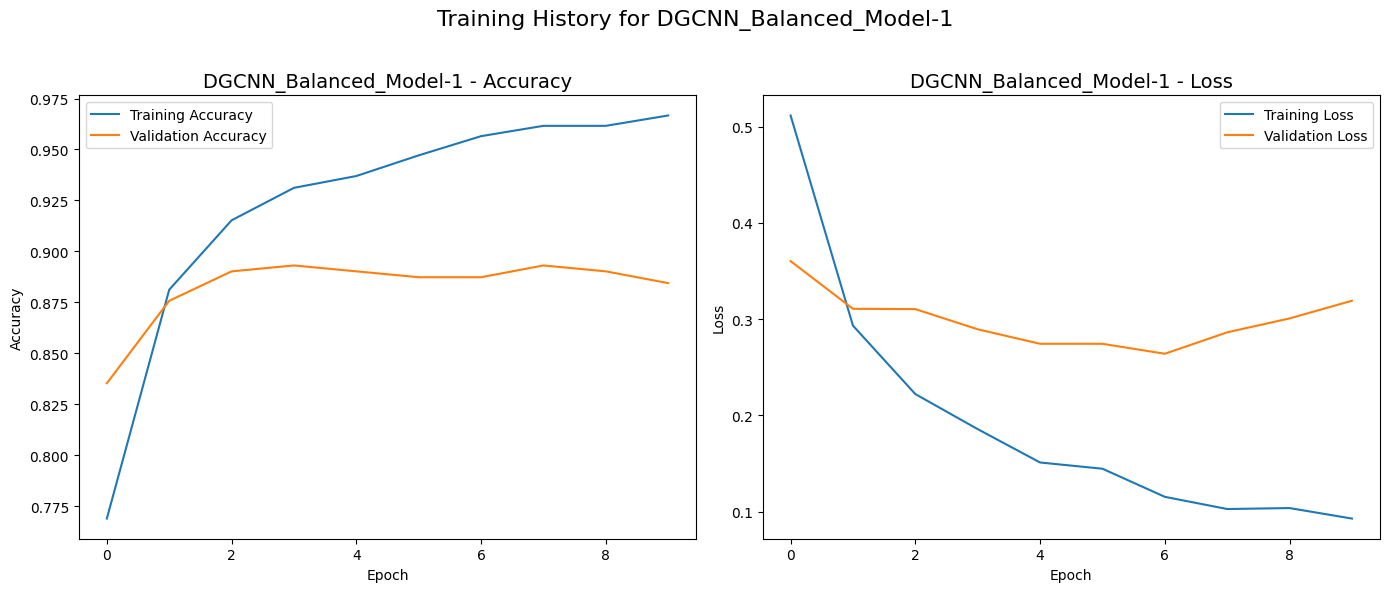

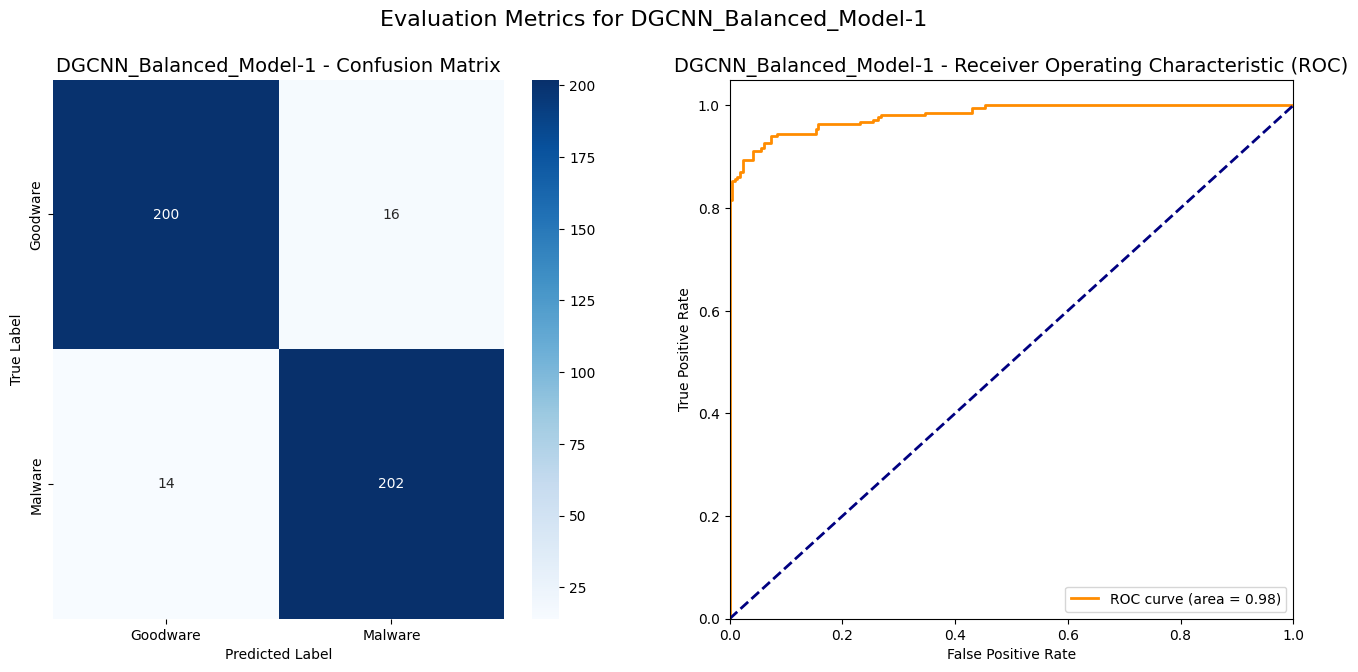

In [6]:
# Experiment 1, Model 1
# Balanced Dataset, DGCNN

data_balanced = pandas.read_csv("../data/processed/balanced_dataset.csv")

X_balanced = data_balanced.drop(["malware"], axis=1)
y_balanced = data_balanced["malware"]

X_graphs_balanced = numpy.load("../data/graphs/balanced_graphs.npy")

X_train_seq_b, X_test_seq_b, y_train_b, y_test_b = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)    

X_train_graph_b, X_test_graph_b, _, _ = train_test_split(
    X_graphs_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)
    
dgcnn_balanced_model = build_dgcnn_model()
train_and_evaluate(
    dgcnn_balanced_model, "DGCNN_Balanced_Model-1",
    [X_train_graph_b, X_train_seq_b], y_train_b,
    [X_test_graph_b, X_test_seq_b], y_test_b
)

Epoch 1/20
439/439 [==============================] - 62s 139ms/step - loss: 0.0703 - accuracy: 0.9811 - auc: 0.9119 - val_loss: 0.0486 - val_accuracy: 0.9839 - val_auc: 0.9781
Epoch 2/20
439/439 [==============================] - 58s 132ms/step - loss: 0.0425 - accuracy: 0.9880 - auc: 0.9598 - val_loss: 0.0395 - val_accuracy: 0.9879 - val_auc: 0.9801
Epoch 3/20
439/439 [==============================] - 57s 131ms/step - loss: 0.0350 - accuracy: 0.9893 - auc: 0.9721 - val_loss: 0.0353 - val_accuracy: 0.9887 - val_auc: 0.9812
Epoch 4/20
439/439 [==============================] - 58s 132ms/step - loss: 0.0287 - accuracy: 0.9910 - auc: 0.9802 - val_loss: 0.0340 - val_accuracy: 0.9899 - val_auc: 0.9829
Epoch 5/20
439/439 [==============================] - 61s 139ms/step - loss: 0.0258 - accuracy: 0.9922 - auc: 0.9849 - val_loss: 0.0364 - val_accuracy: 0.9896 - val_auc: 0.9683
Epoch 6/20
439/439 [==============================] - 58s 132ms/step - loss: 0.0230 - accuracy: 0.9926 - auc: 0.987

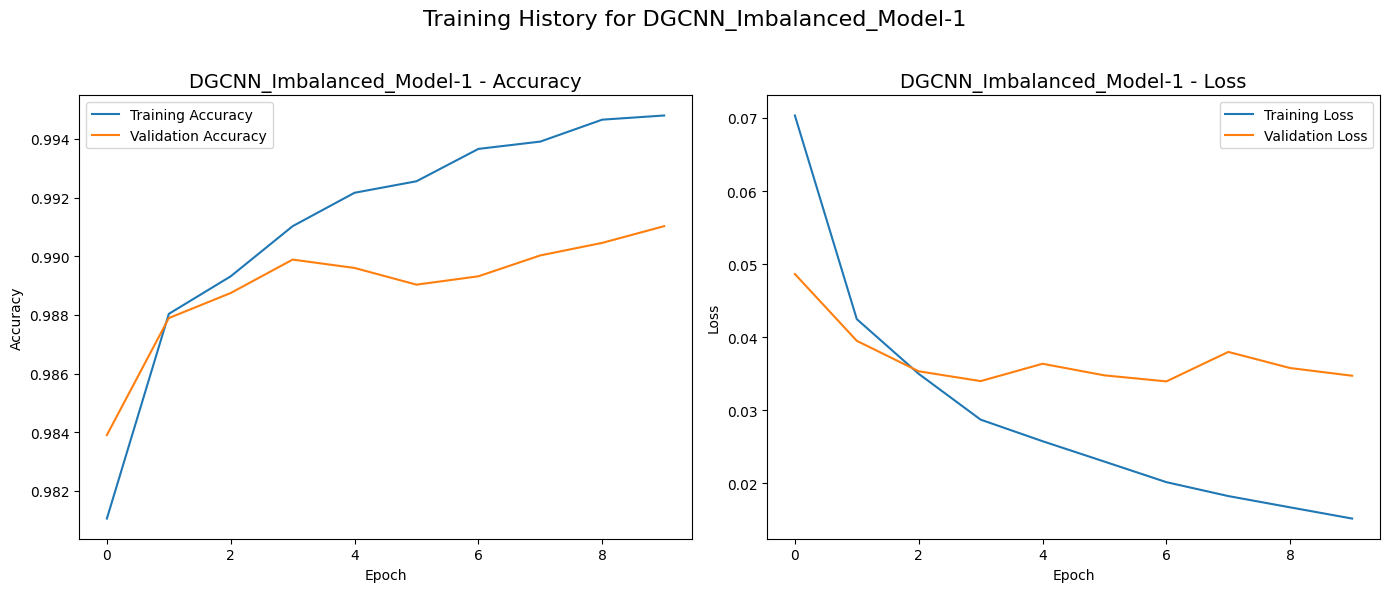

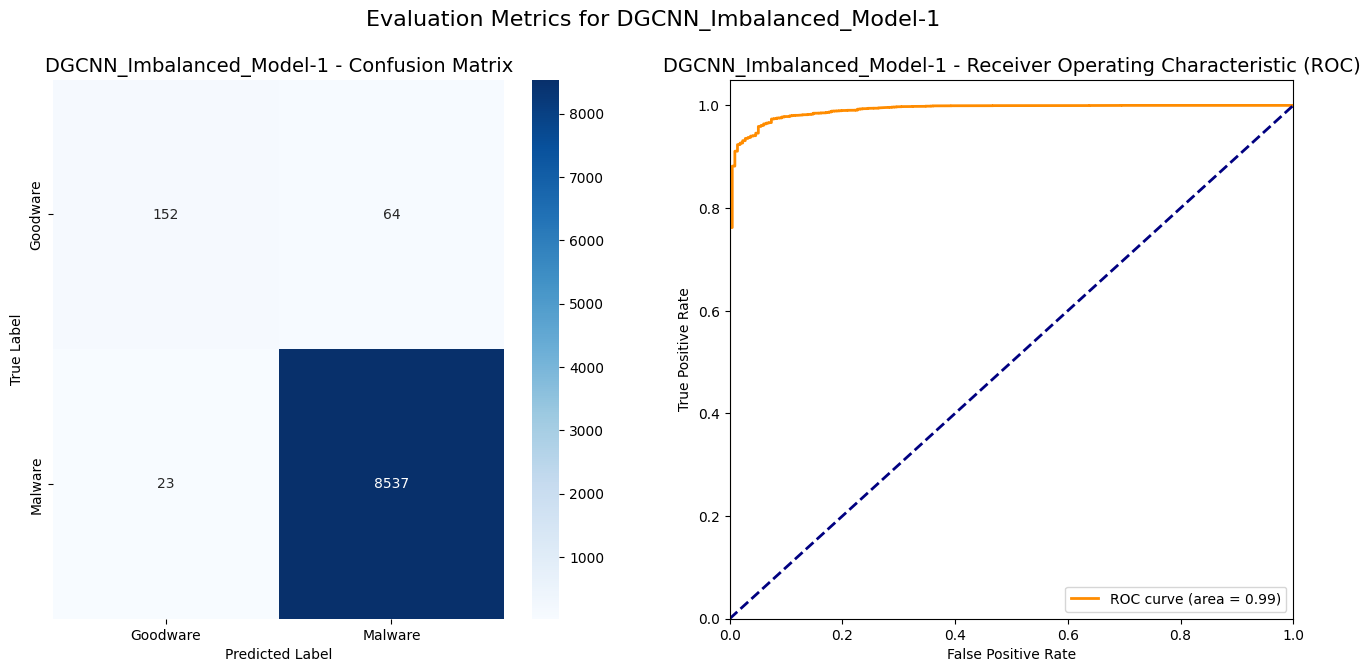

In [7]:
# Experiment 2, Model 1
# Imbalanced Dataset

data_imbalanced = pandas.read_csv("../data/dataset_original.csv")

X_imbalanced = data_imbalanced.drop(["malware","hash"], axis=1)
y_imbalanced = data_imbalanced["malware"]

X_graphs_imbalanced = numpy.load("../data/graphs/imbalanced_graphs.npy",mmap_mode="r")

X_train_seq_b, X_test_seq_b, y_train_b, y_test_b = train_test_split(
    X_imbalanced, y_imbalanced, test_size=0.2, random_state=42, stratify=y_imbalanced
)    

X_train_graph_b, X_test_graph_b, _, _ = train_test_split(
    X_graphs_imbalanced, y_imbalanced, test_size=0.2, random_state=42, stratify=y_imbalanced
)
    
dgcnn_imbalanced_model = build_dgcnn_model()
train_and_evaluate(
    dgcnn_imbalanced_model, "DGCNN_Imbalanced_Model-1",
    [X_train_graph_b, X_train_seq_b], y_train_b,
    [X_test_graph_b, X_test_seq_b], y_test_b
)